In [25]:
# to autoimport edited modules in the notebook
%load_ext autoreload
%autoreload 2

from grsc_cb_model import GRSC_CB_Model
from grsc_cb_instance import GRSC_CB_Instance
import numpy as np
from scipy.spatial import Delaunay, ConvexHull
import networkx as nx

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
# number of land parcels
n = 120
# number of species
m = 10
# number of max connected areas
k = 1
# range of habitat suitability function
w_min, w_max = 20, 100
# range of costs
c_min, c_max = 1, 100
# lambda percentage threshold
lambda_threshold = 0.05
# buffer size
d = 1
# tau
tau = 0.5

External nodes: [64, 35, 99, 7, 73, 42, 14, 110, 80, 16, 113, 52, 53, 22, 56, 25, 28, 95]


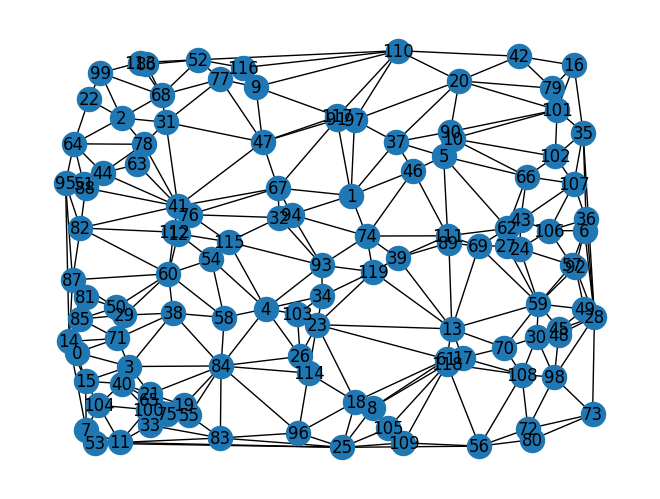

In [27]:
# generate a random instance Delunay graph
points = np.random.rand(n, 2)
tri = Delaunay(points)

G = nx.Graph()
G.add_nodes_from(range(len(points)))

# for each node, it connects it to its neighbors using Delaunay triangulation
for simplex in tri.simplices:
    i, j, h = simplex
    G.add_edge(i, j)
    G.add_edge(j, h)
    G.add_edge(i, h)

# determines the set of external nodes  
external_nodes = set(ConvexHull(points).vertices)
nx.draw(G, points, with_labels=True)
print(f"External nodes: {[int(i) for i in external_nodes]}")

In [28]:
# costs of land parcels
c = {i: np.random.randint(c_min, c_max + 1) for i in G.nodes}

In [29]:
# specie definition
S_1 = list(range(m//3))
S_2 = list(range(m//3, m))
P_1 = len(S_1)
P_2 = len(S_2)

# habitat suitability score function
w = {}
for s in S_1 + S_2:
    prob_zero = 0.2 if s in S_1 else 0.1
    for i in G.nodes:
        if i in external_nodes and s in S_1:
            w[(i, s)] = 0
        elif np.random.rand() < prob_zero:
            w[(i, s)] = 0
        else:
            w[(i, s)] = np.random.randint(w_min, w_max + 1)
            
# suitability quota
lambda_s = {s: lambda_threshold * sum(w[(i, s)] for i in G.nodes) for s in S_1 + S_2}

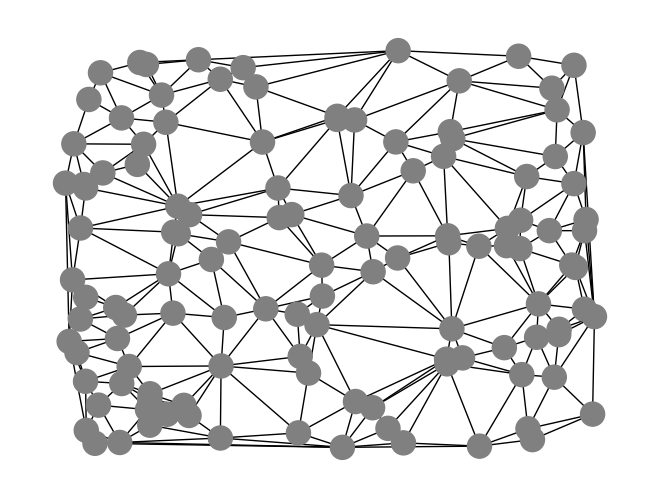

In [30]:
# toy instance
V, E = set(G.nodes), set(G.edges)
instance = GRSC_CB_Instance(V, E, points, 
                            S_1, S_2, P_1, P_2, 
                            k, w, lambda_s, c, d)

instance.draw_graph()


GRSC_CB_Instance(|V|=120, |E|=339, |S1|=3, |S2|=7, P1=3, P2=7, k=1, d=1)
Set parameter LazyConstraints to value 1
Status: 2 Optimal
Objective: 48.0
Nodes in the reserve (x): [8, 48, 49, 96, 102, 112]
Nodes in the core (z): [8, 48, 49, 96, 102, 112]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
r-arc-node separators (y): []


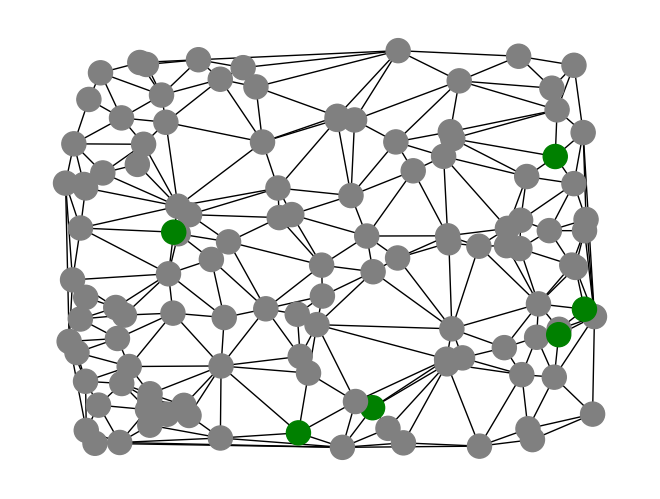

In [31]:
print(instance)
model = GRSC_CB_Model(instance)
model.solve()
model.print_solution()
model.print_graph()

GRSC_CB_Instance(|V|=120, |E|=339, |S1|=3, |S2|=7, P1=3, P2=7, k=1, d=1)
Set parameter LazyConstraints to value 1
Status: 2 Optimal
Objective: 446.0
Nodes in the reserve (x): [0, 3, 14, 15, 29, 38, 50, 60, 71, 81, 85, 87]
Nodes in the core (z): [0, 29, 71, 85]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
r-arc-node separators (y): []


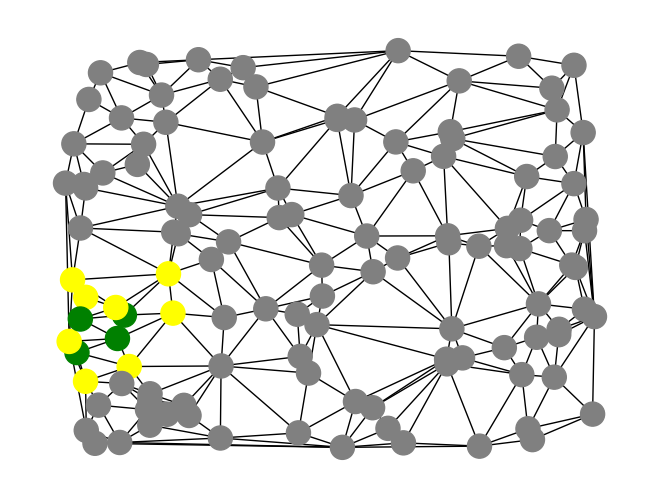

In [32]:
print(instance)
model = GRSC_CB_Model(instance, B=True)
model.solve()
model.print_solution()
model.print_graph()

GRSC_CB_Instance(|V|=120, |E|=339, |S1|=3, |S2|=7, P1=3, P2=7, k=1, d=1)
Set parameter LazyConstraints to value 1
	 * Added constraints: {'corecon-int': 70, 'corecon-frc': 661, 'cover': 0, 'scc-s1': 0, 'scc-s2': 0}
Status: 2 Optimal
Objective: 132.0
Nodes in the reserve (x): [28, 35, 48, 49, 79, 101, 102]
Nodes in the core (z): [48, 49, 79, 101, 102]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
r-arc-node separators (y): [28]


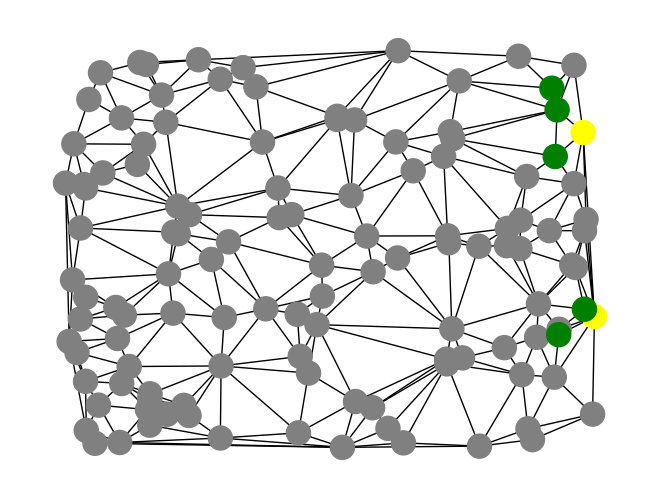

In [33]:
print(instance)
model = GRSC_CB_Model(instance, C=True)
model.solve(verbose=True)
model.print_solution()
model.print_graph()

GRSC_CB_Instance(|V|=120, |E|=339, |S1|=3, |S2|=7, P1=3, P2=7, k=1, d=1)
Set parameter LazyConstraints to value 1
Status: 2 Optimal
Objective: 446.0
Nodes in the reserve (x): [0, 3, 14, 15, 29, 38, 50, 60, 71, 81, 85, 87]
Nodes in the core (z): [0, 29, 71, 85]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
r-arc-node separators (y): [0]


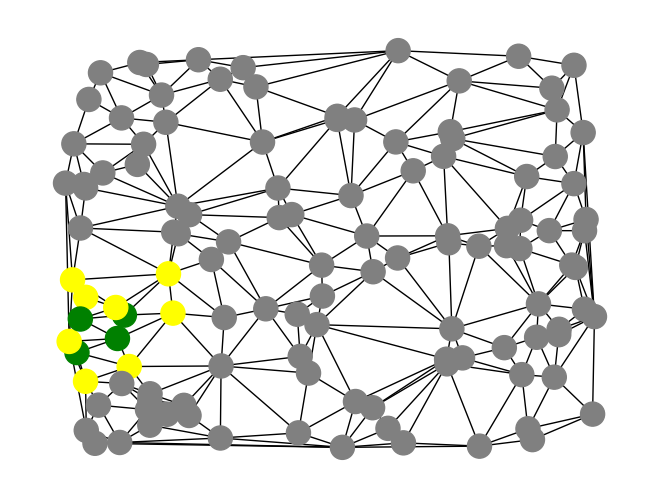

In [34]:
print(instance)
model = GRSC_CB_Model(instance, B=True, C=True)
result = model.solve(basic=True)
model.print_solution()
model.print_graph()

GRSC_CB_Instance(|V|=120, |E|=339, |S1|=3, |S2|=7, P1=3, P2=7, k=1, d=1)
Set parameter LazyConstraints to value 1
	 * Initial solution found with Construction Heuristic. Nodes: {0, 3, 100, 7, 104, 40, np.int32(71), 11, np.int32(14), 15, np.int32(53)}
Status: 2 Optimal
Objective: 446.0
Nodes in the reserve (x): [0, 3, 14, 15, 29, 38, 50, 60, 71, 81, 85, 87]
Nodes in the core (z): [0, 29, 71, 85]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
r-arc-node separators (y): [0]


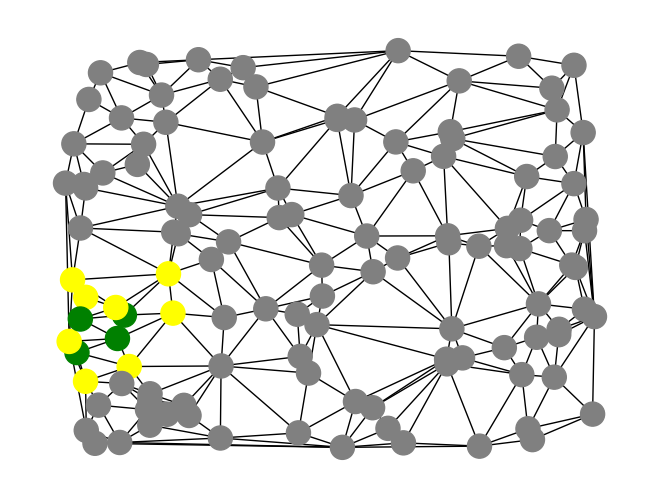

In [35]:
print(instance)
model = GRSC_CB_Model(instance, B=True, C=True)
result = model.solve(basic=True, cp_heuristic=True)
model.print_solution()
model.print_graph()

GRSC_CB_Instance(|V|=120, |E|=339, |S1|=3, |S2|=7, P1=3, P2=7, k=1, d=1)
Set parameter LazyConstraints to value 1
	 * Initial solution found with Construction Heuristic. Nodes: {0, 3, np.int32(38), np.int32(71), 14, np.int32(15), 81, 50, np.int32(85), np.int32(87), np.int32(60), 29}
	 * LB heuristic completed. Best objective: 446.00, Iterations: 4
Status: 2 Optimal
Objective: 446.0
Nodes in the reserve (x): [0, 3, 14, 15, 29, 38, 50, 60, 71, 81, 85, 87]
Nodes in the core (z): [0, 29, 71, 85]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
r-arc-node separators (y): [0]


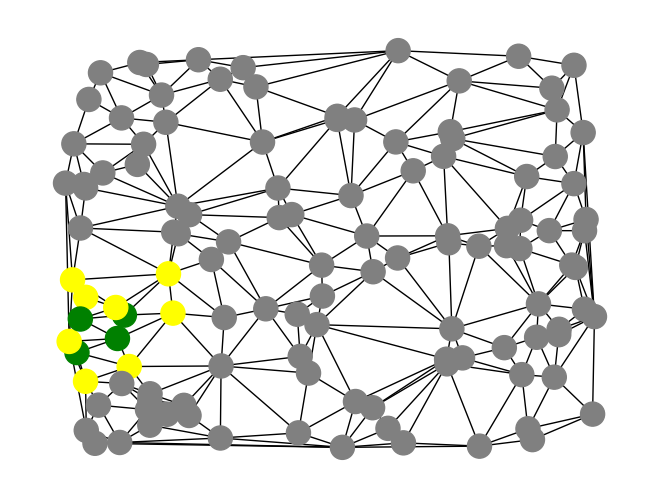

In [36]:
print(instance)
model = GRSC_CB_Model(instance, B=True, C=True)
result = model.solve(basic=True, cp_heuristic=True, lb_heuristic=True, verbose=True)
model.print_solution()
model.print_graph()